## Vector Analysis
This notebook will contain notes on how to visualize vector fields. Solving div, grad, and curl problems.

# Visualizing Vector fields
$$\vec{f}(x,y) = \sin(x)\hat{x} + \cos(y)\hat{y} $$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

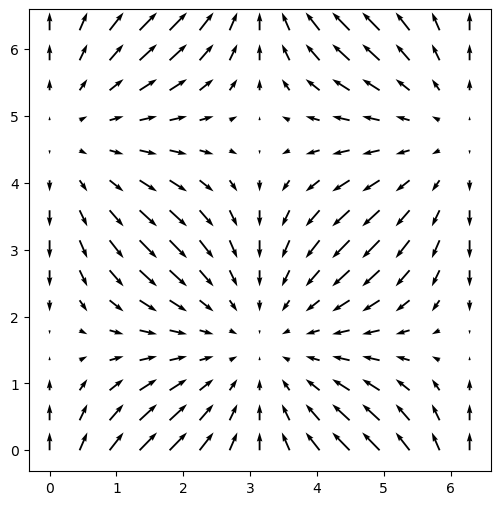

In [38]:
x_range = np.linspace(0, 2*np.pi, 15)
y_range = np.linspace(0, 2*np.pi, 15)

x, y = np.meshgrid(x_range, y_range)  #our set of points
fx, fy = np.sin(x), np.cos(y)      #our vector functions

plt.figure(figsize=(6, 6))
plt.quiver(x, y, fx, fy)  ##quiver is how visualize our vectors

plt.axis("scaled")
plt.show()

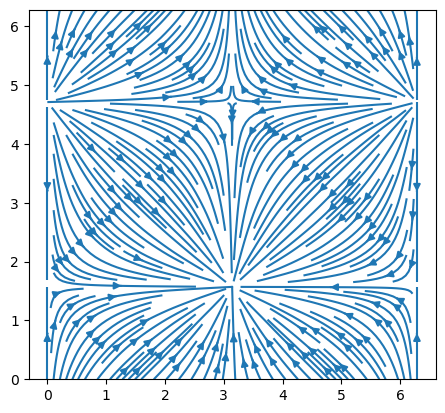

In [39]:
plt.streamplot(x, y, fx, fy, density = 2)
plt.axis("scaled")
plt.show()

## Outward Radial Field
$$
\vec{F}_A=x\hat{x}+y\hat{y},
$$


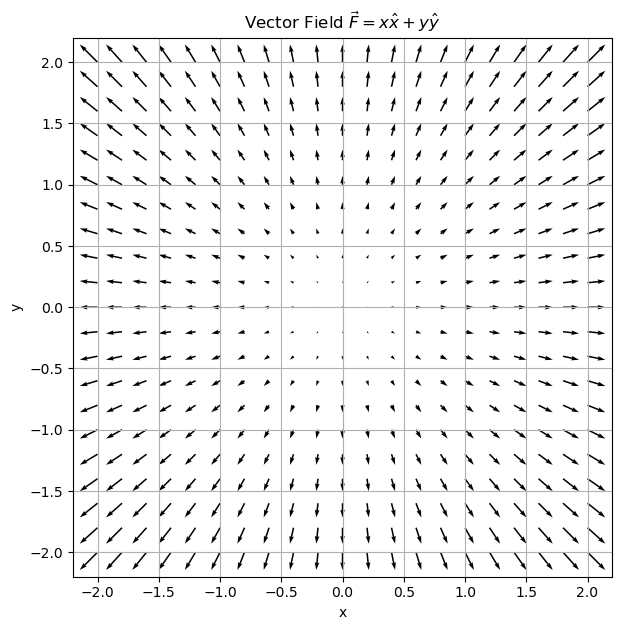

In [11]:
#radially outward field A
x = np.linspace(-2, 2, 21)
y = np.linspace(-2, 2, 21)

X, Y = np.meshgrid(x,y)

Fx = X
Fy = Y

plt.figure(figsize=(7, 7))
plt.quiver(X, Y, Fx, Fy)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Vector Field $\vec{F}=x\hat{x}+y\hat{y}$")
plt.grid(True)
plt.gca().set_aspect("equal")
plt.show()

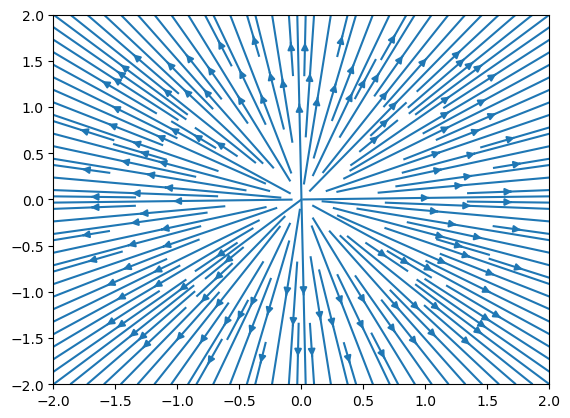

In [8]:
plt.streamplot(X, Y, Fx, Fy, density = 2)

# Numerical Divergence
For
$$
\vec{F}=F_x\hat{x}+F_y\hat{y},
$$

$$
\nabla\cdot\vec{F}=\frac{\partial F_x}{\partial x}+\frac{\partial F_y}{\partial y}.
$$

For

$$
\vec{F}=x\hat{x}+y\hat{y},
$$

the exact divergence is
$$
\nabla\cdot\vec{F}=1+1=2.
$$

In [13]:
x = np.linspace(-2, 2, 101)
y = np.linspace(-2, 2, 101)
X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]

Fx = X
Fy = Y

# np.gradient uses axis=0 for y and axis=1 for x
dFx_dx = np.gradient(Fx, dx, axis=1)  #np.gradient takes the numerical derivative for you
dFy_dy = np.gradient(Fy, dy, axis=0)

div_F = dFx_dx + dFy_dy
print(div_F)
print("Average divergence =", np.mean(div_F))

[[2. 2. 2. ... 2. 2. 2.]
 [2. 2. 2. ... 2. 2. 2.]
 [2. 2. 2. ... 2. 2. 2.]
 ...
 [2. 2. 2. ... 2. 2. 2.]
 [2. 2. 2. ... 2. 2. 2.]
 [2. 2. 2. ... 2. 2. 2.]]
Average divergence = 1.9999999999999987


# Numerical Curl
For a two-dimensional vector field,

$$
(\nabla\times\vec{F})_z=\frac{\partial F_y}{\partial x}-\frac{\partial F_x}{\partial y}.
$$

For the rotational field

$$
\vec{F}=-y\hat{x}+x\hat{y},
$$

the exact curl is

$$
(\nabla\times\vec{F})_z=2.
$$

In [14]:
#we are making numerical curl function
def numerical_curl_z(Fx, Fy, dx, dy):
    dFy_dx = np.gradient(Fy, dx, axis=1)
    dFx_dy = np.gradient(Fx, dy, axis=0)
    return dFy_dx - dFx_dy

#applying the curcl function we made
Fx = -Y
Fy = X

curl_z = numerical_curl_z(Fx, Fy, dx, dy)

print("Average numerical curl:", np.mean(curl_z))

Average numerical curl: 1.9999999999999987


# Numerical Line Integrals
A line integral around a closed curve is

$$
\oint_C \vec{F}\cdot d\vec{r}.
$$

For

$$
\vec{F}=-y\hat{x}+x\hat{y},
$$

Take C to be a circle of radius R:
$x = R\cos\theta$ and $y = R\sin\theta$

In [17]:
# parametrizing the cruve numerically
R = 1.0

theta = np.linspace(0, 2*np.pi, 1001)

x_curve = R * np.cos(theta)
y_curve = R * np.sin(theta)

#evaulating the field along the curve:
Fx_curve = -y_curve
Fy_curve = x_curve

#dx dy using np.diff which calculate the difference bewteen consectuve elements.
#it represents individual steps forward along the curve
dx_curve = np.diff(x_curve)
dy_curve = np.diff(y_curve)

#midpoint approximation. 
Fx_mid = 0.5 * (Fx_curve[:-1] + Fx_curve[1:])
Fy_mid = 0.5 * (Fy_curve[:-1] + Fy_curve[1:])

#summing everything up
circulation = np.sum(Fx_mid * dx_curve + Fy_mid * dy_curve)

print("Numerical circulation =", circulation)
print("Expected value         =", 2*np.pi*R**2)

Numerical circulation = 6.283143965558951
Expected value         = 6.283185307179586


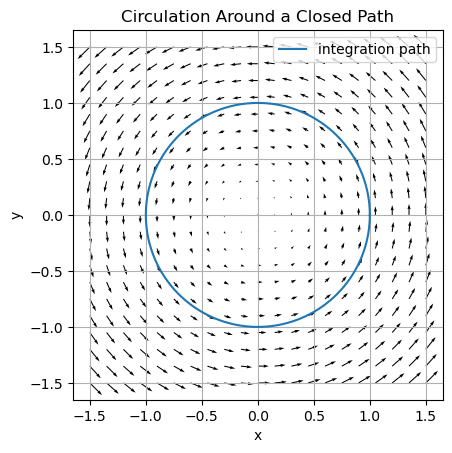

In [21]:
#Visualizng vector field and integration path
x = np.linspace(-1.5, 1.5, 21)
y = np.linspace(-1.5, 1.5, 21)

X, Y = np.meshgrid(x, y)

Fx = -Y
Fy = X

plt.figure()

plt.quiver(X, Y, Fx, Fy)
plt.plot(x_curve, y_curve, label='integration path')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Circulation Around a Closed Path')
plt.legend()
plt.grid()
plt.gca().set_aspect("equal")
plt.show()

# Numerical Flux through a closed curve
The outward flux through a closed curve is

$$
\oint_C \vec{F}\cdot\hat{n}\,ds.
$$

For

$$
\vec{F}=x\hat{x}+y\hat{y},
$$

and a circle of radius \(R\), the exact outward flux is

$$
\oint_C \vec{F}\cdot\hat{n}\,ds=2\pi R^2.
$$

In [23]:
#making the circle
R = 1.0

theta = np.linspace(0, 2*np.pi, 10000)

x_curve = R * np.cos(theta)
y_curve = R * np.sin(theta)

#Evuauating the field
Fx_curve = x_curve
Fy_curve = y_curve

# normal unit vector
nx = np.cos(theta)
ny = np.sin(theta)

#arc length
dtheta = theta[1] - theta[0]
ds = R * dtheta

#computing the flux
F_dot_n = Fx_curve * nx + Fy_curve * ny
flux = np.sum(F_dot_n[:-1]) * ds

print("Numerical flux =", flux)
print("Expected flux  =", 2*np.pi*R**2)

Numerical flux = 6.283185307179586
Expected flux  = 6.283185307179586


# Eletric Field from Point Charges

For one point charge

$$
\vec{E} =
kq\frac{\vec{r}-\vec{r}_q}{|\vec{r}-\vec{r}_q|^3}.
$$
where $r_q$ is the position vector of the soruce charge q and $r$ is the position vector of where you want to calculate the electric field

In [25]:
def electric_field(X, Y, q, xq, yq, k=1.0):
    #dispalcement vectors
    Rx = X - xq
    Ry = Y - yq

    #distance magnitude
    R = np.sqrt(Rx**2 + Ry**2)

    # Avoid division by zero. Where the charges live
    R = np.where(R < 0.1, np.nan, R)

    #computing the E field components
    Ex = k * q * Rx / R**3
    Ey = k * q * Ry / R**3

    return Ex, Ey

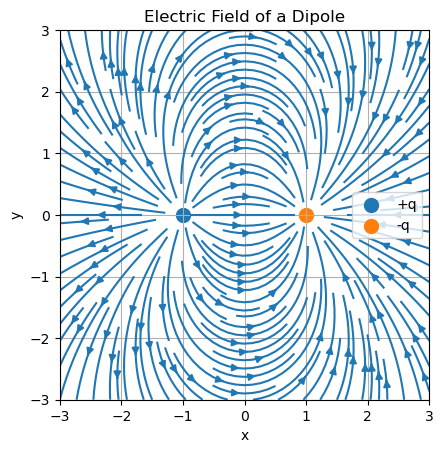

In [26]:
# creating a dipole
x = np.linspace(-3, 3, 50)
y = np.linspace(-3, 3, 50)

X, Y = np.meshgrid(x, y)

Ex1, Ey1 = electric_field(X, Y, q=1, xq=-1, yq=0)
Ex2, Ey2 = electric_field(X, Y, q=-1, xq=1, yq=0)

Ex = Ex1 + Ex2
Ey = Ey1 + Ey2

plt.figure()
plt.streamplot(X, Y, Ex, Ey, density=1.5)
plt.scatter(-1, 0, s=100, label='+q')
plt.scatter(1, 0, s=100, label='-q')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Electric Field of a Dipole')
plt.legend()
plt.grid()
plt.gca().set_aspect('equal')
plt.show()